# Building an Image Classifier with PyTorch

**Carlos Fernandez**

This notebook reproduces the chapter 10 Fashion-MNIST image-classifier workflow using PyTorch. It keeps the test set isolated until the final evaluation.


## Imports, reproducibility, and device selection

This cell imports the required libraries, fixes all requested random seeds so the split and training are repeatable, and selects the best available accelerator.


In [1]:
from pathlib import Path
import platform
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import v2

SEED = 42
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.1
DATA_DIR = Path("prob5/data")
CURVES_PATH = Path("prob5/training_curves.png")
CHECKPOINT_PATH = Path("prob5/image_classifier.pt")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")


Python: 3.11.16
NumPy: 2.4.6
PyTorch: 2.14.0+cpu
Device: cpu


## Load and inspect Fashion-MNIST

This cell uses the official torchvision FashionMNIST datasets and the v2 image-to-float-tensor transform. The seeded 55,000/5,000 split is made only from training data; the test data remains untouched.


In [2]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

train_full = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=transform)
train_dataset, validation_dataset = random_split(
    train_full,
    [55_000, 5_000],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Split sizes: train={len(train_dataset)}, validation={len(validation_dataset)}, test={len(test_dataset)}")
print(f"Batch image shape/dtype: {images.shape}, {images.dtype}")
print(f"Batch label shape/dtype: {labels.shape}, {labels.dtype}")
print(f"Pixel range: [{images.min().item():.1f}, {images.max().item():.1f}]")
print(f"Class names: {train_full.classes}")


Split sizes: train=55000, validation=5000, test=10000
Batch image shape/dtype: torch.Size([32, 1, 28, 28]), torch.float32
Batch label shape/dtype: torch.Size([32]), torch.int64
Pixel range: [0.0, 1.0]
Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## Define and validate the classifier

This cell creates the requested fully connected neural network. It returns raw logits because `CrossEntropyLoss` applies the needed normalization internally; shape and parameter-count assertions catch architecture mistakes.


In [3]:
class ImageClassifier(nn.Module):
    def __init__(self, input_features=28 * 28, hidden1=300, hidden2=100, num_classes=10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_features, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        return self.network(x)

model = ImageClassifier().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

with torch.no_grad():
    logits = model(images.to(device))
assert logits.shape == (images.shape[0], 10)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
assert parameter_count == 266_610
print(f"Output shape: {tuple(logits.shape)}")
print(f"Trainable parameters: {parameter_count:,}")


Output shape: (32, 10)
Trainable parameters: 266,610


## Train and validate for ten epochs

This cell implements the optimization loop explicitly. It sets training/evaluation modes appropriately, resets gradients every update, and records loss and accuracy for both the training and validation splits. The test set is not used here.


In [4]:
def evaluate(data_loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.no_grad():
        for batch_images, batch_labels in data_loader:
            batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)
            batch_logits = model(batch_images)
            total_loss += loss_fn(batch_logits, batch_labels).item() * batch_labels.size(0)
            total_correct += (batch_logits.argmax(dim=1) == batch_labels).sum().item()
            total_examples += batch_labels.size(0)
    return total_loss / total_examples, total_correct / total_examples

history = {"train_loss": [], "train_accuracy": [], "validation_loss": [], "validation_accuracy": []}
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss_total = 0.0
    train_correct = 0
    train_examples = 0
    for batch_images, batch_labels in train_loader:
        batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)
        optimizer.zero_grad()
        batch_logits = model(batch_images)
        loss = loss_fn(batch_logits, batch_labels)
        loss.backward()
        optimizer.step()

        train_loss_total += loss.item() * batch_labels.size(0)
        train_correct += (batch_logits.argmax(dim=1) == batch_labels).sum().item()
        train_examples += batch_labels.size(0)

    train_loss = train_loss_total / train_examples
    train_accuracy = train_correct / train_examples
    validation_loss, validation_accuracy = evaluate(validation_loader)
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(validation_accuracy)
    print(
        f"Epoch {epoch:02d}/{EPOCHS}: train loss={train_loss:.4f}, train accuracy={train_accuracy:.4f}, "
        f"validation loss={validation_loss:.4f}, validation accuracy={validation_accuracy:.4f}"
    )


Epoch 01/10: train loss=0.6032, train accuracy=0.7798, validation loss=0.4407, validation accuracy=0.8388


Epoch 02/10: train loss=0.4054, train accuracy=0.8495, validation loss=0.3984, validation accuracy=0.8514


Epoch 03/10: train loss=0.3650, train accuracy=0.8649, validation loss=0.3679, validation accuracy=0.8658


Epoch 04/10: train loss=0.3340, train accuracy=0.8756, validation loss=0.3687, validation accuracy=0.8584


Epoch 05/10: train loss=0.3156, train accuracy=0.8825, validation loss=0.3589, validation accuracy=0.8658


Epoch 06/10: train loss=0.2974, train accuracy=0.8882, validation loss=0.3858, validation accuracy=0.8566


Epoch 07/10: train loss=0.2859, train accuracy=0.8921, validation loss=0.3365, validation accuracy=0.8764


Epoch 08/10: train loss=0.2735, train accuracy=0.8964, validation loss=0.3268, validation accuracy=0.8820


Epoch 09/10: train loss=0.2652, train accuracy=0.8998, validation loss=0.3316, validation accuracy=0.8794


Epoch 10/10: train loss=0.2527, train accuracy=0.9045, validation loss=0.3144, validation accuracy=0.8874


## Plot learning curves

This cell visualizes the recorded accuracy and loss histories. It saves the required image in `prob5/` and also displays it for interactive notebook use.


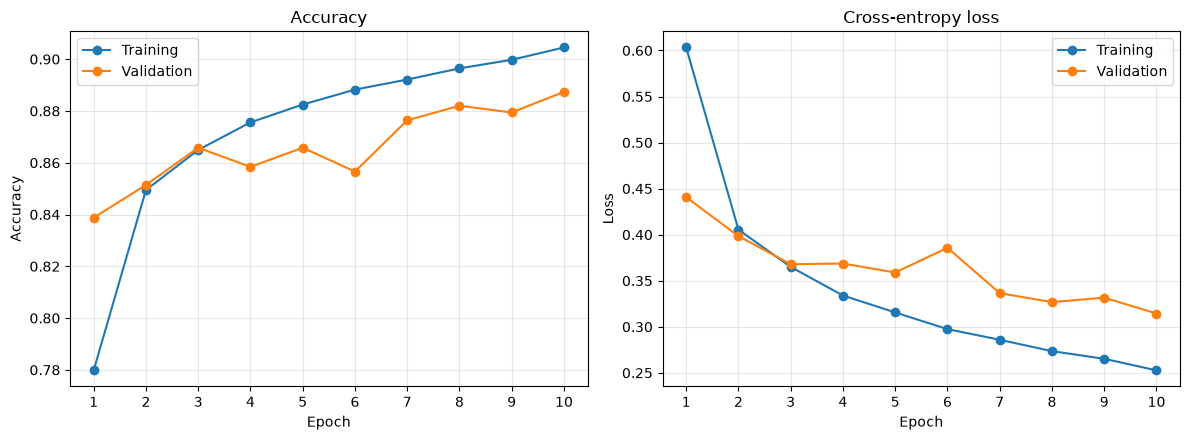

In [5]:
epoch_numbers = range(1, EPOCHS + 1)
fig, (accuracy_ax, loss_ax) = plt.subplots(1, 2, figsize=(12, 4.5))
accuracy_ax.plot(epoch_numbers, history["train_accuracy"], marker="o", label="Training")
accuracy_ax.plot(epoch_numbers, history["validation_accuracy"], marker="o", label="Validation")
accuracy_ax.set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy", xticks=list(epoch_numbers))
accuracy_ax.legend()
accuracy_ax.grid(alpha=0.3)
loss_ax.plot(epoch_numbers, history["train_loss"], marker="o", label="Training")
loss_ax.plot(epoch_numbers, history["validation_loss"], marker="o", label="Validation")
loss_ax.set(title="Cross-entropy loss", xlabel="Epoch", ylabel="Loss", xticks=list(epoch_numbers))
loss_ax.legend()
loss_ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(CURVES_PATH, dpi=150, bbox_inches="tight")
plt.show()


## Evaluate once on held-out test data

This cell makes the only test-set accuracy calculation, after all model and training decisions are complete. It then reports predictions, true labels, and top-three softmax probabilities for three test images.


In [6]:
test_loss, test_accuracy = evaluate(test_loader)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

model.eval()
example_images, example_labels = next(iter(test_loader))
with torch.no_grad():
    example_probabilities = model(example_images[:3].to(device)).softmax(dim=1).cpu()
for index, (probabilities, true_label) in enumerate(zip(example_probabilities, example_labels[:3]), start=1):
    top_probabilities, top_indices = probabilities.topk(3)
    top_three = [(test_dataset.classes[class_index], round(probability.item(), 4))
                 for probability, class_index in zip(top_probabilities, top_indices)]
    print(
        f"Test image {index}: predicted={test_dataset.classes[probabilities.argmax().item()]}, "
        f"true={test_dataset.classes[true_label.item()]}, top-3={top_three}"
    )


Test loss: 0.3338
Test accuracy: 0.8845
Test image 1: predicted=Ankle boot, true=Ankle boot, top-3=[('Ankle boot', 0.9528), ('Sneaker', 0.0262), ('Sandal', 0.0209)]
Test image 2: predicted=Pullover, true=Pullover, top-3=[('Pullover', 0.9993), ('Coat', 0.0005), ('Shirt', 0.0001)]
Test image 3: predicted=Trouser, true=Trouser, top-3=[('Trouser', 1.0), ('Dress', 0.0), ('T-shirt/top', 0.0)]


## Save and reload the trained model

This cell saves the model `state_dict` together with its constructor hyperparameters. It reloads weights safely, rebuilds the model, and verifies that both models produce identical logits.


In [7]:
constructor_hyperparameters = {
    "input_features": 28 * 28,
    "hidden1": 300,
    "hidden2": 100,
    "num_classes": 10,
}
torch.save(
    {"state_dict": model.state_dict(), "constructor_hyperparameters": constructor_hyperparameters},
    CHECKPOINT_PATH,
)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
reloaded_model = ImageClassifier(**checkpoint["constructor_hyperparameters"]).to(device)
reloaded_model.load_state_dict(checkpoint["state_dict"])
reloaded_model.eval()
with torch.no_grad():
    original_outputs = model(example_images[:3].to(device))
    reloaded_outputs = reloaded_model(example_images[:3].to(device))
assert torch.equal(original_outputs, reloaded_outputs)
print(f"Saved and reloaded identical outputs from {CHECKPOINT_PATH}")


Saved and reloaded identical outputs from prob5\image_classifier.pt
